In [18]:
import pandas as pd

file='등급별 평균 및 표준편차.xlsx'


In [19]:
# 방법 1: MultiIndex 컬럼으로 처리
def load_with_multiindex(file_path):
    """
    MultiIndex 컬럼으로 데이터를 로드하는 방법
    """
    # header=[0,1]로 두 행을 모두 헤더로 사용
    dataframe1 = pd.read_excel(file_path, header=[0, 1], index_col=0)
    
    # 컬럼명 정리 (NaN 값들을 적절히 처리)
    dataframe1.columns = pd.MultiIndex.from_tuples([
        (col[0] if pd.notna(col[0]) else '', col[1] if pd.notna(col[1]) else '')
        for col in dataframe1.columns
    ])
    
    return dataframe1

In [20]:
df_multiindex = load_with_multiindex(file)
df_multiindex

매출액                         영업이익                \
                 mean(평균)      std(표준편차)          mean           std   
신용등급                                                                   
AAA         127409.692308  142596.149202  13167.461538  18678.247735   
AA+          82775.333333  108426.179506     24.000000   2900.866250   
AA          154436.785714  144304.494168  18647.642857  56867.248018   
AA-          66250.714286   62022.082883   1926.928571   2490.719095   
A+          107010.333333  218286.809618   5702.444444   9253.471310   
A            37692.714286   33433.782455   1396.714286   2281.891373   
A-           14586.333333   11545.729005    472.000000    488.496469   
BBB+         48268.500000   40857.971150   1660.000000   2000.729922   
BBB           7717.428571    4997.177499     72.857143    696.520980   
BBB-         10711.250000    4322.955808    426.500000    308.300178   
BB+           9396.750000    7448.898548  -1220.250000   2917.091859   
BB            5946.800000    5822.537479     72.400000    284.677537   
BB-           2677.000000    2553.354656     70.833333    168.178972   
B+            6580.200000    8704.941568    276.600000    451.314524   
B             5736.500000    2697.612370   -218.000000    349.310750   
B-            4176.500000    2082.429471    270.000000    148.492424   
CC            3411.000000            NaN   -696.000000           NaN   
C            26862.000000            NaN    206.000000           NaN   
NaN                   NaN            NaN           NaN           NaN   
NaN                   NaN            NaN           NaN           NaN   
NaN                   NaN            NaN           NaN           NaN   
NaN                   NaN            NaN           NaN           NaN   
등급별 데이터 수:            NaN            NaN           NaN           NaN   
AAA     13            NaN            NaN           NaN           NaN   
AA+      3            NaN            NaN           NaN           NaN   
AA       7            NaN            NaN           NaN           NaN   
AA-     10            NaN            NaN           NaN           NaN   
A+       9            NaN            NaN           NaN           NaN   
A        4            NaN            NaN           NaN           NaN   
A-       5            NaN            NaN           NaN           NaN   
BBB+     9            NaN            NaN           NaN           NaN   
BBB      5            NaN            NaN           NaN           NaN   
BBB-     2            NaN            NaN           NaN           NaN   
BB+      5            NaN            NaN           NaN           NaN   
BB       4            NaN            NaN           NaN           NaN   
BB-      5            NaN            NaN           NaN           NaN   
B+       5            NaN            NaN           NaN           NaN   
B        3            NaN            NaN           NaN           NaN   
B-       5            NaN            NaN           NaN           NaN   
CCC      4            NaN            NaN           NaN           NaN   
CC       1            NaN            NaN           NaN           NaN   
C        1            NaN            NaN           NaN           NaN   

                   당기순이익                          총자산                 \
                    mean           std           mean            std   
신용등급                                                                   
AAA          8501.461538  15158.748484  352196.307692  256789.888764   
AA+           171.666667   1747.328914  142381.666667  173189.703251   
AA          13936.928571  47440.503721  298366.285714  313481.907261   
AA-          -281.000000   5907.486762   70421.142857   73825.908785   
A+           3800.666667   6091.834391  125756.777778  237046.527721   
A            1042.142857   1688.586532   57263.285714   36626.800792   
A-           -618.666667   1177.018380   23126.000000   14952.282889   
BBB+          968.700000   1591.423405   71959.200000   73023

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (matplotlib에서 한글 표시용)
plt.rcParams['font.family'] = ['DejaVu Sans', 'Malgun Gothic']
plt.rcParams['axes.unicode_minus'] = False

In [27]:
class MultivariateCompanyDataGenerator:
    def __init__(self, df_multiindex):
        """
        MultiIndex DataFrame을 입력받아 초기화
        상관관계를 고려한 다변량 정규분포 기반 데이터 생성
        """
        self.df = df_multiindex
        self.financial_metrics = [
            '매출액', '영업이익', '당기순이익', '총자산', '총부채', 
            '자본총계', '자본금', '영업활동현금흐름', '이자발생부채'
        ]
        # 양수만 가능한 지표들
        self.positive_only_metrics = ['매출액', '총자산', '자본금', '자본총계']
        
        # 기본 상관관계 행렬 (실제 데이터가 없을 때 사용할 현실적인 상관관계)
        self.default_correlation = self._create_default_correlation_matrix()
        
    def _create_default_correlation_matrix(self):
        """
        재무지표 간의 현실적인 상관관계 행렬 생성
        """
        metrics = self.financial_metrics
        n = len(metrics)
        corr_matrix = np.eye(n)  # 단위행렬로 시작
        
        # 현실적인 상관관계 설정
        correlations = {
            ('매출액', '영업이익'): 0.85,
            ('매출액', '당기순이익'): 0.75,
            ('매출액', '총자산'): 0.70,
            ('매출액', '영업활동현금흐름'): 0.65,
            ('영업이익', '당기순이익'): 0.90,
            ('영업이익', '영업활동현금흐름'): 0.70,
            ('당기순이익', '영업활동현금흐름'): 0.60,
            ('총자산', '총부채'): 0.80,
            ('총자산', '자본총계'): 0.60,
            ('총자산', '이자발생부채'): 0.70,
            ('총부채', '이자발생부채'): 0.85,
            ('자본총계', '자본금'): 0.40,
        }
        
        # 상관관계 행렬 채우기
        for (metric1, metric2), corr_val in correlations.items():
            if metric1 in metrics and metric2 in metrics:
                idx1 = metrics.index(metric1)
                idx2 = metrics.index(metric2)
                corr_matrix[idx1, idx2] = corr_val
                corr_matrix[idx2, idx1] = corr_val
        
        return corr_matrix
    
    def _calculate_correlation_matrix(self, credit_grade, original_data=None):
        """
        특정 신용등급의 상관관계 행렬 계산
        원본 데이터가 있으면 사용하고, 없으면 기본값 사용
        """
        if original_data is not None:
            # 실제 데이터에서 상관관계 계산
            grade_data = original_data[original_data['신용등급'] == credit_grade]
            if len(grade_data) > 10:  # 충분한 데이터가 있을 때만
                correlation_matrix = grade_data[self.financial_metrics].corr().values
                # NaN 값 처리
                correlation_matrix = np.nan_to_num(correlation_matrix, nan=0.0)
                # 대각선을 1로 설정
                np.fill_diagonal(correlation_matrix, 1.0)
                return correlation_matrix
        
        # 기본 상관관계 행렬 사용
        return self.default_correlation.copy()
    
    def _ensure_positive_definite(self, matrix):
        """
        행렬이 양정치(positive definite)가 되도록 조정
        다변량 정규분포에서 공분산 행렬은 반드시 양정치여야 함
        """
        # 고유값 분해
        eigenvals, eigenvecs = np.linalg.eigh(matrix)
        
        # 음수 고유값을 작은 양수로 조정
        eigenvals = np.maximum(eigenvals, 1e-8)
        
        # 행렬 재구성
        matrix_fixed = eigenvecs @ np.diag(eigenvals) @ eigenvecs.T
        
        return matrix_fixed
    
    def _create_covariance_matrix(self, means, stds, correlation_matrix):
        """
        평균, 표준편차, 상관관계 행렬로부터 공분산 행렬 생성
        """
        # 표준편차 대각행렬
        std_matrix = np.diag(stds)
        
        # 공분산 행렬 = D * R * D (D: 표준편차 행렬, R: 상관관계 행렬)
        covariance_matrix = std_matrix @ correlation_matrix @ std_matrix
        
        # 양정치 보장
        covariance_matrix = self._ensure_positive_definite(covariance_matrix)
        
        return covariance_matrix
    
    def _apply_financial_constraints(self, data_dict):
        """
        재무지표 간의 회계적 제약조건 적용
        """
        # 제약조건 1: 자본총계 = 총자산 - 총부채
        if all(key in data_dict for key in ['총자산', '총부채', '자본총계']):
            calculated_equity = data_dict['총자산'] - data_dict['총부채']
            # 원래 값과 계산된 값의 평균 사용 (완전히 대체하지 않고 조정)
            data_dict['자본총계'] = (data_dict['자본총계'] + calculated_equity) / 2
        
        # 제약조건 2: 영업이익은 매출액의 -50% ~ 50% 범위
        if '매출액' in data_dict and '영업이익' in data_dict:
            max_operating_income = data_dict['매출액'] * 0.5
            min_operating_income = data_dict['매출액'] * -0.5
            data_dict['영업이익'] = np.clip(data_dict['영업이익'], 
                                       min_operating_income, max_operating_income)
        
        # 제약조건 3: 당기순이익은 영업이익보다 작거나 같아야 함 (일반적으로)
        if '영업이익' in data_dict and '당기순이익' in data_dict:
            if data_dict['영업이익'] > 0:
                # 영업이익이 양수일 때, 당기순이익은 영업이익의 150% 이하
                data_dict['당기순이익'] = min(data_dict['당기순이익'], 
                                        data_dict['영업이익'] * 1.5)
        
        # 제약조건 4: 양수만 가능한 지표들 처리
        for metric in self.positive_only_metrics:
            if metric in data_dict:
                data_dict[metric] = max(data_dict[metric], 0.1)
        
        # 제약조건 5: 자본금은 자본총계보다 작아야 함
        if '자본금' in data_dict and '자본총계' in data_dict:
            if data_dict['자본총계'] > 0:
                data_dict['자본금'] = min(data_dict['자본금'], data_dict['자본총계'])
        
        return data_dict
    
    def _validate_financial_ratios(self, data_dict):
        """
        생성된 데이터의 재무비율이 현실적인지 검증
        """
        issues = []
        
        # ROA (자산수익률) 검증: -50% ~ 50%
        if '당기순이익' in data_dict and '총자산' in data_dict and data_dict['총자산'] > 0:
            roa = data_dict['당기순이익'] / data_dict['총자산']
            if abs(roa) > 0.5:
                issues.append(f"ROA가 비현실적: {roa:.2%}")
        
        # 부채비율 검증: 0% ~ 500%
        if '총부채' in data_dict and '자본총계' in data_dict and data_dict['자본총계'] > 0:
            debt_ratio = data_dict['총부채'] / data_dict['자본총계']
            if debt_ratio > 5.0 or debt_ratio < 0:
                issues.append(f"부채비율이 비현실적: {debt_ratio:.2f}")
        
        # 영업이익률 검증: -100% ~ 100%
        if '영업이익' in data_dict and '매출액' in data_dict and data_dict['매출액'] > 0:
            operating_margin = data_dict['영업이익'] / data_dict['매출액']
            if abs(operating_margin) > 1.0:
                issues.append(f"영업이익률이 비현실적: {operating_margin:.2%}")
        
        return len(issues) == 0, issues
    
    def generate_company_data(self, credit_grade, company_name=None, seed=None, 
                            max_attempts=100, original_data=None):
        """
        다변량 정규분포와 제약조건을 사용한 기업 데이터 생성
        
        Parameters:
        - credit_grade: 신용등급
        - company_name: 생성할 기업명
        - seed: 랜덤 시드
        - max_attempts: 최대 시도 횟수
        - original_data: 상관관계 계산용 원본 데이터 (선택사항)
        """
        if seed is not None:
            np.random.seed(seed)
            
        if credit_grade not in self.df.index:
            raise ValueError(f"신용등급 '{credit_grade}'이 데이터에 없습니다.")
        
        # 해당 등급의 통계 데이터 가져오기
        grade_data = self.df.loc[credit_grade]
        
        # 평균과 표준편차 추출
        means = []
        stds = []
        valid_metrics = []
        
        for metric in self.financial_metrics:
            try:
                # df_multiindex 구조에 맞게 수정: (metric, 'mean(평균)') 형태
                mean_val = grade_data[(metric, 'mean(평균)')]
                std_val = grade_data[(metric, 'std(표준편차)')]
                
                if not (pd.isna(mean_val) or pd.isna(std_val)):
                    means.append(mean_val)
                    stds.append(std_val)
                    valid_metrics.append(metric)
            except KeyError:
                # 다른 가능한 컬럼명 패턴도 시도
                try:
                    mean_val = grade_data[(metric, 'mean')]
                    std_val = grade_data[(metric, 'std')]
                    
                    if not (pd.isna(mean_val) or pd.isna(std_val)):
                        means.append(mean_val)
                        stds.append(std_val)
                        valid_metrics.append(metric)
                except KeyError:
                    continue
        
        if len(valid_metrics) < 2:
            raise ValueError(f"유효한 지표가 너무 적습니다: {len(valid_metrics)}개")
        
        means = np.array(means)
        stds = np.array(stds)
        
        # 상관관계 행렬 계산
        correlation_matrix = self._calculate_correlation_matrix(credit_grade, original_data)
        
        # 유효한 지표에 맞게 상관관계 행렬 조정
        if len(valid_metrics) != len(self.financial_metrics):
            valid_indices = [self.financial_metrics.index(metric) for metric in valid_metrics]
            correlation_matrix = correlation_matrix[np.ix_(valid_indices, valid_indices)]
        
        # 공분산 행렬 생성
        covariance_matrix = self._create_covariance_matrix(means, stds, correlation_matrix)
        
        # 다변량 정규분포에서 샘플링 (여러 번 시도)
        for attempt in range(max_attempts):
            try:
                # 다변량 정규분포에서 샘플 생성
                sample = np.random.multivariate_normal(mean=means, cov=covariance_matrix)
                
                # 딕셔너리로 변환
                data_dict = dict(zip(valid_metrics, sample))
                
                # 제약조건 적용
                data_dict = self._apply_financial_constraints(data_dict)
                
                # 재무비율 검증
                is_valid, issues = self._validate_financial_ratios(data_dict)
                
                if is_valid:
                    # 성공적으로 생성됨
                    break
                elif attempt == max_attempts - 1:
                    # 마지막 시도에서도 실패하면 경고만 출력하고 사용
                    print(f"Warning: 재무비율 검증 실패 (시도 {max_attempts}회): {issues}")
                    
            except Exception as e:
                if attempt == max_attempts - 1:
                    raise Exception(f"데이터 생성 실패 (시도 {max_attempts}회): {e}")
                continue
        
        # 누락된 지표는 NaN으로 설정
        for metric in self.financial_metrics:
            if metric not in data_dict:
                data_dict[metric] = np.nan
        
        # Series로 변환
        company_data = pd.Series(data_dict)
        company_data.name = company_name or f"Generated_Company_{credit_grade}"
        
        return company_data
    
    def generate_multiple_companies(self, credit_grade, num_companies=10, 
                                  name_prefix="Company", original_data=None, 
                                  include_credit_grade=True):  # 수정: 파라미터 추가
        """
        동일한 신용등급으로 여러 기업 데이터 생성
        """
        companies = []
        successful_generations = 0
        
        for i in range(num_companies * 2):  # 실패 대비해서 더 많이 시도
            try:
                company_name = f"{name_prefix}_{credit_grade}_{successful_generations+1:02d}"
                company_data = self.generate_company_data(
                    credit_grade, company_name, seed=i, original_data=original_data
                )
                companies.append(company_data)
                successful_generations += 1
                
                if successful_generations >= num_companies:
                    break
                    
            except Exception as e:
                print(f"기업 {i+1} 생성 실패: {e}")
                continue
        
        if len(companies) == 0:
            raise Exception(f"{credit_grade} 등급 기업 생성에 완전히 실패했습니다.")
        
        # DataFrame으로 변환
        result_df = pd.DataFrame(companies)
        
        # 수정: 신용등급 컬럼 추가 옵션
        if include_credit_grade:
            result_df['신용등급'] = credit_grade
            # 신용등급 컬럼을 맨 앞으로 이동
            cols = ['신용등급'] + [col for col in result_df.columns if col != '신용등급']
            result_df = result_df[cols]
        
        return result_df
    
    def generate_companies_all_grades(self, num_per_grade=10, name_prefix="Company", 
                                    original_data=None):
        """
        모든 신용등급에 대해 기업 데이터 생성
        """
        all_companies = []
        
        for grade in self.df.index:
            try:
                print(f"{grade} 등급 기업 생성 중...")
                grade_companies = self.generate_multiple_companies(
                    grade, num_per_grade, name_prefix, original_data, include_credit_grade=True
                )
                all_companies.append(grade_companies)
                print(f"{grade} 등급: {len(grade_companies)}개 기업 생성 완료")
            except Exception as e:
                print(f"{grade} 등급 생성 중 오류: {e}")
        
        if all_companies:
            result_df = pd.concat(all_companies, ignore_index=True)
            return result_df
        else:
            return pd.DataFrame()
    
    def analyze_correlations(self, generated_data, credit_grade=None):
        """
        생성된 데이터의 상관관계 분석
        """
        if credit_grade:
            # 수정: 신용등급 컬럼이 있는지 확인
            if '신용등급' in generated_data.columns:
                data_subset = generated_data[generated_data['신용등급'] == credit_grade]
                title_suffix = f" ({credit_grade} 등급)"
            else:
                # 신용등급 컬럼이 없으면 전체 데이터 사용하고 경고 출력
                print(f"Warning: '신용등급' 컬럼이 없어서 전체 데이터로 분석합니다.")
                data_subset = generated_data
                title_suffix = f" (전체 데이터 - {credit_grade} 등급으로 생성됨)"
        else:
            data_subset = generated_data
            title_suffix = " (전체)"
        
        # 상관관계 행렬 계산
        correlation_matrix = data_subset[self.financial_metrics].corr()
        
        # 히트맵 그리기
        plt.figure(figsize=(12, 10))
        plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
        plt.colorbar(label='Correlation Coefficient')
        plt.title(f'재무지표 상관관계 행렬{title_suffix}')
        
        # 축 레이블 설정
        plt.xticks(range(len(self.financial_metrics)), self.financial_metrics, rotation=45)
        plt.yticks(range(len(self.financial_metrics)), self.financial_metrics)
        
        # 상관계수 텍스트 표시
        for i in range(len(self.financial_metrics)):
            for j in range(len(self.financial_metrics)):
                plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', 
                        ha='center', va='center', fontsize=8)
        
        plt.tight_layout()
        plt.show()
        
        return correlation_matrix
    
    def save_to_csv(self, data, filename, folder_path="generated_data"):
        """
        생성된 데이터를 CSV 파일로 저장
        """
        # 폴더가 없으면 생성
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)
        
        # 파일 경로 생성
        file_path = os.path.join(folder_path, f"{filename}.csv")
        
        # CSV로 저장
        if isinstance(data, pd.Series):
            data.to_csv(file_path, encoding='utf-8-sig')
        else:
            data.to_csv(file_path, index=False, encoding='utf-8-sig')
        
        print(f"데이터가 저장되었습니다: {file_path}")
        return file_path

    def compare_statistics(self, original_stats, generated_data, credit_grade):
        """
        원본 통계와 생성된 데이터의 통계 비교
        
        Parameters:
        - original_stats: 원본 통계 데이터 (MultiIndex DataFrame)
        - generated_data: 생성된 기업 데이터 (DataFrame)
        - credit_grade: 비교할 신용등급
        """
        print(f"\n=== {credit_grade} 등급 통계 비교 ===")
        
        # 신용등급 컬럼이 있는지 확인
        if '신용등급' in generated_data.columns:
            grade_data = generated_data[generated_data['신용등급'] == credit_grade]
        else:
            # 신용등급 컬럼이 없으면 전체 데이터를 해당 등급으로 간주
            grade_data = generated_data
            print(f"Warning: '신용등급' 컬럼이 없어서 전체 데이터를 {credit_grade} 등급으로 간주합니다.")
        
        print(f"생성된 데이터: {len(grade_data)}개 기업\n")
        
        # 각 재무지표별로 통계 비교
        for metric in self.financial_metrics:
            if metric in grade_data.columns:
                try:
                    # 원본 데이터에서 평균과 표준편차 추출
                    original_mean = None
                    original_std = None
                    
                    # 패턴 1: (metric, 'mean(평균)')
                    if (metric, 'mean(평균)') in original_stats.columns:
                        original_mean = original_stats.loc[credit_grade, (metric, 'mean(평균)')]
                        original_std = original_stats.loc[credit_grade, (metric, 'std(표준편차)')]
                    # 패턴 2: (metric, 'mean')
                    elif (metric, 'mean') in original_stats.columns:
                        original_mean = original_stats.loc[credit_grade, (metric, 'mean')]
                        original_std = original_stats.loc[credit_grade, (metric, 'std')]
                    
                    if original_mean is not None and not pd.isna(original_mean):
                        # 생성된 데이터의 통계 계산
                        generated_mean = grade_data[metric].mean()
                        generated_std = grade_data[metric].std()
                        
                        # 결과 출력
                        print(f"{metric}:")
                        print(f"  원본    - 평균: {original_mean:>15,.0f}, 표준편차: {original_std:>15,.0f}")
                        print(f"  생성됨  - 평균: {generated_mean:>15,.0f}, 표준편차: {generated_std:>15,.0f}")
                        
                        # 차이 계산 및 출력
                        mean_diff = abs(generated_mean - original_mean)
                        std_diff = abs(generated_std - original_std)
                        
                        # 상대적 차이 (%)
                        mean_rel_diff = (mean_diff / abs(original_mean)) * 100 if original_mean != 0 else 0
                        std_rel_diff = (std_diff / abs(original_std)) * 100 if original_std != 0 else 0
                        
                        print(f"  절대차이 - 평균: {mean_diff:>15,.0f}, 표준편차: {std_diff:>15,.0f}")
                        print(f"  상대차이 - 평균: {mean_rel_diff:>14.1f}%, 표준편차: {std_rel_diff:>14.1f}%")
                        print()
                    else:
                        print(f"{metric}: 원본 데이터에서 찾을 수 없음")
                        
                except Exception as e:
                    print(f"{metric}: 처리 중 오류 발생 - {e}")
                    continue

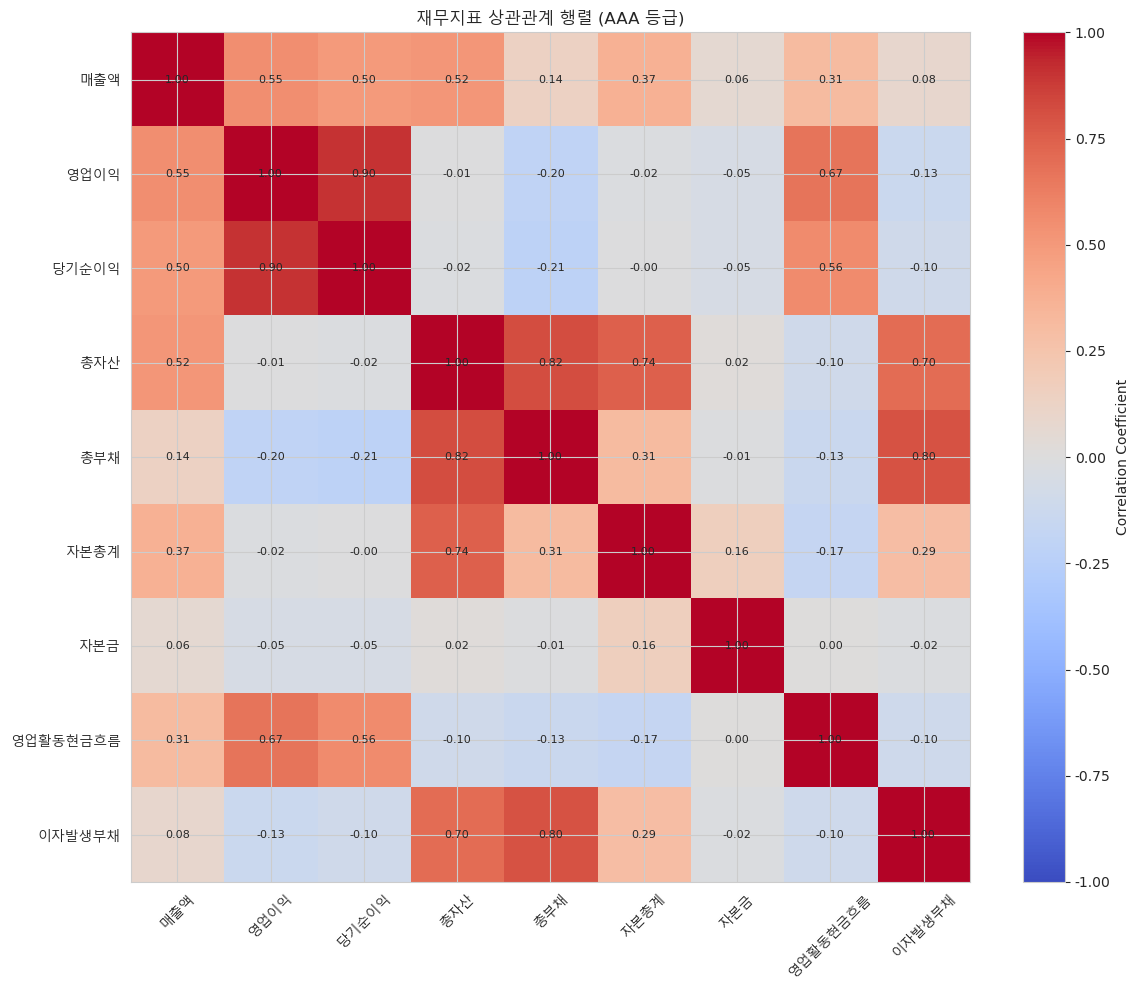


=== AAA 등급 통계 비교 ===
생성된 데이터: 100개 기업

매출액:
  원본    - 평균:         127,410, 표준편차:         142,596
  생성됨  - 평균:         197,673, 표준편차:         118,280
  절대차이 - 평균:          70,264, 표준편차:          24,316
  상대차이 - 평균:           55.1%, 표준편차:           17.1%

영업이익:
  원본    - 평균:          13,167, 표준편차:          18,678
  생성됨  - 평균:          20,408, 표준편차:          18,775
  절대차이 - 평균:           7,241, 표준편차:              97
  상대차이 - 평균:           55.0%, 표준편차:            0.5%

당기순이익:
  원본    - 평균:           8,501, 표준편차:          15,159
  생성됨  - 평균:          14,495, 표준편차:          16,194
  절대차이 - 평균:           5,994, 표준편차:           1,035
  상대차이 - 평균:           70.5%, 표준편차:            6.8%

총자산:
  원본    - 평균:         352,196, 표준편차:         256,790
  생성됨  - 평균:         463,064, 표준편차:         213,712
  절대차이 - 평균:         110,867, 표준편차:          43,078
  상대차이 - 평균:           31.5%, 표준편차:           16.8%

총부채:
  원본    - 평균:         203,071, 표준편차:         156,032
  생성됨  - 평균:         217,552, 표준편차:    

In [29]:
# 1. 초기화
generator = MultivariateCompanyDataGenerator(df_multiindex)

# 2. AAA 등급 기업 100개 생성
companies = generator.generate_multiple_companies('AAA', num_companies=100)

# 3. 상관관계 확인 (히트맵으로 시각화)
correlation_matrix = generator.analyze_correlations(companies, 'AAA')

# 4. 원본과 생성된 데이터 통계 비교
generator.compare_statistics(df_multiindex, companies, 'AAA')

# 6. 저장
generator.save_to_csv(companies, "multivariate_generated_companies")

# 7. 통계 비교
generator.compare_statistics(df_multiindex, companies, 'AAA')

In [ ]:
# 사용 예시
"""
# 1. 기본 사용법
generator = MultivariateCompanyDataGenerator(df_multiindex)

# 2. 단일 기업 생성
single_company = generator.generate_company_data('AAA')

# 3. 여러 기업 생성
multiple_companies = generator.generate_multiple_companies('AAA', num_companies=100)

# 4. 모든 등급의 기업 생성
all_companies = generator.generate_companies_all_grades(num_per_grade=50)

# 5. 상관관계 분석
correlation_matrix = generator.analyze_correlations(all_companies, 'AAA')

# 6. 저장
generator.save_to_csv(all_companies, "multivariate_generated_companies")

# 7. 통계 비교
generator.compare_statistics(df_multiindex, all_companies, 'AAA')
"""